In [24]:
"""
Imports nécessaires pour le TP PCA + SVM.

Ce module contient tous les imports requis pour l'optimisation d'hyperparamètres
avec PCA et SVM, en suivant les bonnes pratiques Python.
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from typing import Tuple, List, Optional

# Configuration matplotlib pour l'affichage interactif
plt.ion()

## Aide en python !!

Si vous n'êtes **pas à l'aise en python et numpy**, voyez aussi ces TPs comme un entrainement, il est de toute façon nécessaire de maitriser ces outils pour le ML.

Dans ce TP, nous allons appliquer la PCA à nos données, observer les résultats.

Nous n'allons pas coder la PCA from scratch, mais en utilisant sklearn, comme avec le TP précédent, c'est donc également une façon de continuer de se familiariser avec cette bibliothèque.

## Partie 0 : choix du dataset



### Dataset 1 : très bien pour commencer mais très petit, donc les expériences donneront des résultat plutôt peu intéressants dessus.

Todo : observez la taille du dataset et affichez la ci dessous.

In [25]:
# Dataset 1: Chiffres manuscrits sklearn
num_classes = 10
X, y = load_digits(n_class=num_classes, return_X_y=True)
dim_representation = 8

# Ratios pour la division des données
train_ratio = 0.6  # Peut être réduit pour les gros datasets
valid_ratio = 0.3  # Peut être réduit pour les gros datasets

print(f"Dataset chargé: {X.shape[0]} échantillons, {X.shape[1]} features") #TODO

Dataset chargé: 1797 échantillons, 64 features


### Dataset 2: mieux car plus grand, donc résultats plus intéressants. Attention, les expériences peuvent mettre du temps à tourner.

**Ignorez ce dataset au début, n'essayez de le charger que à la fin du TP, pour affiner le résultat de vos expériences**

Il peut être intéressant de commencer vos recherche sur une version plus petite du dataset (en gardant que 10% des data par exemple), et quand votre code marche bien et que vous avez resserré la plage de valeurs des hyper-paramètre qui est vraisemblablement la bonne, faire une recherche plus précise sur l'ensemble du dataset.

Astuce: en particulier, n'utilisez pas un grand nombre de composantes PCA sur ce dataset (en tout cas ne faites pas PCA(grand n_comp) + featureMap_polynomiale(degré2) + SVM là dessus.

À aller chercher sur : https://gitlab.inria.fr/flandes/data-for-teaching

Dans le shell linux, faites:
`wget https://gitlab.inria.fr/flandes/data-for-teaching/-/raw/master/mnist70.npz?inline=false`


In [26]:
#!wget https://gitlab.inria.fr/flandes/data-for-teaching/-/raw/master/mnist70.npz
## remarque: ça ne marchera pas sur jupyter-cloud, dans ce cas téléchargez le fichier 
## en local, puis faite un upload vers votre cloud.

In [27]:
# Dataset 2: MNIST plus complet
if False:
    try:
        # Adaptez le chemin selon votre configuration
        load_object = np.load("mnist70.npz")
        dim_representation = 28
        X = load_object["X"]
        y = load_object["y"]
        del load_object

        # Ratios réduits pour un développement plus rapide
        train_ratio = 0.1  # 10% pour l'entraînement lors du développement
        valid_ratio = 0.1  # 10% pour la validation
        print(f"Dataset chargé: {'COMPLETER'} échantillons, {'COMPLETER'} features") #TODO
        
    except FileNotFoundError:
        print("Fichier MNIST non trouvé, utilisez le dataset 1 ou téléchargez depuis:")
        print(
            "wget https://gitlab.inria.fr/flandes/data-for-teaching/-/raw/master/mnist70.npz"
        )

## Partie 1 -- PCA: prise en main

Ici, on souhaite faire une première PCA sur les données de MNIST (où n’importe quelles données visuelles).

1. Calculer la transformée en PCA des données en conservant 95% de la variance des données. Doit-on
   calculer la PCA seulement sur les données d’entraînement, ou bien sur l’ensemble (train+validation) ?
   Pourquoi ? (Quel est le risque, dans le mauvais cas ?)
2. Extraire le nombre de composantes effectivement retenues par la décomposition.
3. [on vous donne le code] observer le tracé du ratio de variance expliquée en fonction du nombre de composantes.
4. À partir de la version transformée des données, calculer aussi leur version décompressée (par transformée
   inverse). Afficher quelques exemples de avant/après (compression+décompression). On peut jouer avec
   le taux de variance expliquée et voir l’effet sur les images. (il est recommandé d’écrire une fonction).
5. (optionnel) Calculer l’erreur de reconstruction moyenne sur toutes les images (c’est plus facile que pour une seule
   image). Le faire aussi pour l’ensemble de valdiation.
6. (optionnel) Calculer l’erreur de reconstruciton pour une seule image. (inclure ceci dans la fonction de comparaison
   avant/après).

Toutes ces étapes vont être réalisées une par une dans la suite du notebook, vous pouvez continuer la lecture.


In [28]:
# Rien à compléter ici, la fonction est déjà écrite.
def visualize_sample(
    X: np.ndarray, y: np.ndarray, index: int, dim_repr: int
) -> None:
    """
    Affiche un échantillon du dataset sous forme d'image.

    Args:
        X: Tableau des caractéristiques (N_samples x D_features)
        y: Tableau des labels correspondants
        index: Index de l'échantillon à afficher
        dim_repr: Dimension de représentation (largeur = hauteur)
    """
    plt.figure(figsize=(6, 4))
    plt.imshow(X[index].reshape(dim_repr, dim_repr), cmap=cm.gray)
    plt.title(f"Échantillon {index}: classe {y[index]}")
    plt.axis("off")
    plt.show()

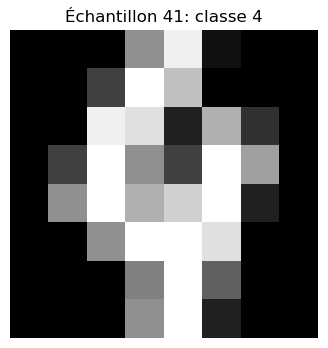

In [29]:
# Visualisation d'un exemple
sample_index = 41
visualize_sample(X, y, sample_index, dim_representation)

In [30]:
# Rien à compléter ici, la fonction est déjà écrite.
def split_dataset(
    X: np.ndarray,
    y: np.ndarray,
    train_ratio: float,
    valid_ratio: float,
) -> tuple[np.ndarray, ...]:
    """
    Divise le dataset en ensembles d'entraînement, validation et test.

    Division non-aléatoire mais déterministe pour la reproductibilité.

    Args:
        X: Données d'entrée (N_samples x D_features)
        y: Labels correspondants
        train_ratio: Proportion pour l'entraînement (0.0 à 1.0)
        valid_ratio: Proportion pour la validation (0.0 à 1.0)

    Returns:
        Tuple contenant (X_train, y_train, X_valid, y_valid, X_test, y_test)

    Raises:
        AssertionError: Si les ratios ne permettent pas d'avoir un ensemble de test
    """
    assert isinstance(train_ratio, float), "Avez vous choisi un ratio ?"
    assert isinstance(valid_ratio, float), "Avez vous choisi un ratio ?"
    test_ratio = 1 - train_ratio - valid_ratio
    assert test_ratio > 0, (
        "Erreur: Les ratios doivent laisser de la place pour un ensemble de test"
    )

    total_samples = X.shape[0]
    train_size = int(train_ratio * total_samples)
    valid_size = int(valid_ratio * total_samples)

    # Division séquentielle
    X_train = X[:train_size].copy()
    y_train = y[:train_size].copy()

    X_valid = X[train_size : train_size + valid_size].copy()
    y_valid = y[train_size : train_size + valid_size].copy()

    X_test = X[train_size + valid_size :].copy()
    y_test = y[train_size + valid_size :].copy()

    assert y_test.shape[0] > 1, (
        "Erreur: L'ensemble de test doit contenir au moins 2 échantillons"
    )

    print("Division du dataset:")
    print(f"- Entraînement: {X_train.shape[0]} échantillons")
    print(f"- Validation: {X_valid.shape[0]} échantillons")
    print(f"- Test: {X_test.shape[0]} échantillons")

    return X_train, y_train, X_valid, y_valid, X_test, y_test

In [31]:
# TODO: Complétez les valeurs et effectuez la division (regardez la description de la fonction split_dataset)
ratio_train = 0.6
ratio_valid = 0.2
X_train, y_train, X_valid, y_valid, X_test, y_test = split_dataset(X,y,ratio_train,ratio_valid)

Division du dataset:
- Entraînement: 1078 échantillons
- Validation: 359 échantillons
- Test: 360 échantillons


### Ici, allez voir la doc en ligne de `sklearn.decomposition.PCA`

En particulier, il y est question d'un argument d'entrée `n_components` et d'un attribut `explained_variance_ratio_`


In [32]:
?sklearn.decomposition.PCA


Init signature:
sklearn.decomposition.PCA(
    n_components=None,
    *,
    copy=True,
    whiten=False,
    svd_solver='auto',
    tol=0.0,
    iterated_power='auto',
    n_oversamples=10,
    power_iteration_normalizer='auto',
    random_state=None,
)
Docstring:     
Principal component analysis (PCA).

Linear dimensionality reduction using Singular Value Decomposition of the
data to project it to a lower dimensional space. The input data is centered
but not scaled for each feature before applying the SVD.

It uses the LAPACK implementation of the full SVD or a randomized truncated
SVD by the method of Halko et al. 2009, depending on the shape of the input
data and the number of components to extract.

With sparse inputs, the ARPACK implementation of the truncated SVD can be
used (i.e. through :func:`scipy.sparse.linalg.svds`). Alternatively, one
may consider :class:`TruncatedSVD` where the data are not centered.

Notice that this class only supports sparse inputs for some solvers s

In [33]:
# Premier essai de PCA avec un ratio de variance expliquée fixé à 95%
explained_variance_threshold = 0.95

# TODO: Créez un objet PCA avec le bon paramètre n_components
pca_processor = sklearn.decomposition.PCA(n_components=explained_variance_threshold)

# TODO: Ajustez la PCA sur les données d'entraînement uniquement
# IMPORTANT: Ne jamais utiliser les données de validation/test pour ajuster la PCA !
pca_processor.fit(X_train)

print(f"PCA ajustée avec seuil de variance: {explained_variance_threshold}")


PCA ajustée avec seuil de variance: 0.95


# Explication complémentaire:

Petite explication sur l'utilisation du parametre `n_components` dans la classe PCA de sklearn :

Python est très flexible, donc:

- si la valeur passée pour `n_components` est de type `int`, alors sklearn interprète cette valeur comme le nombre de composantes à garder dans la PCA (c'est le $D'$ de mon cours)
- si la valeur passée pour `n_components` est de type `float` (et on espère, entre 0 et 1), sklearn l'interprète comme un ratio de variance expliquée désirée.
  Dans ce 2ème cas, l'idée est la suivante: la variance des données est aussi égale à la somme des valeurs propres ($\lambda_1+\lambda_2+\ldots +\lambda_D$).
  Si on garde par exemple que 2 composantes (les 2 premières), on aura une variance des données apres projection égale a $\lambda_1+\lambda_2$.
  Le ratio de variance "expliquée" (c.a.d. préservée par la PCA) sera de $$\frac{\lambda_1+\lambda_2}{\lambda_1+\lambda_2+\ldots +\lambda_D}$$
  Ainsi, si la valeur passée pour `n_components` est de type `float`, sklearn cherche des $\lambda$ jusqu'à ce que leur somme fasse 95% de la variance totale des données. Ainsi, il choisit le $D'$ à votre place... mais bon, vous avez choisi 95%, ce qui est aussi arbitraire (mais moins arbitraire que dire "gardons 10 composantes" ou bien "gardons 10% des composantes").


In [34]:
# Analyse du nombre de composantes retenues
print(f"Nombre de composantes retenues: {pca_processor.n_components_}")#TODO

Nombre de composantes retenues: 28


/tmp/ipykernel_566785/3584668073.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


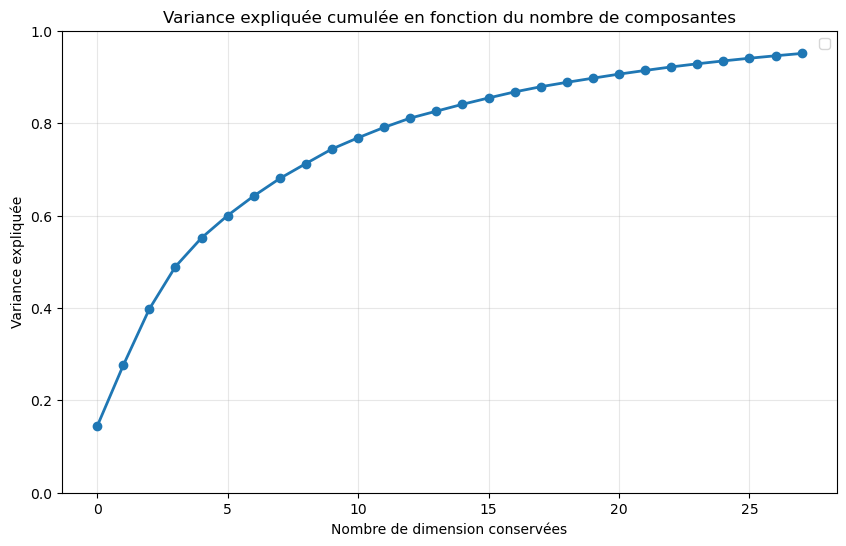

In [35]:
#TODO Ici vous devez "seulement" comprendre ce que la fonction affiche et compléter la légende en fonction
def plot_explained_variance(pca: sklearn.decomposition.PCA) -> None:
    """
    Trace la variance expliquée cumulée en fonction du nombre de composantes.

    Args:
        pca: Objet PCA ajusté
    """
    cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_explained_variance, marker="o", linewidth=2)
    plt.xlabel("Nombre de dimension conservées") #TODO
    plt.ylabel("Variance expliquée") #TODO
    plt.title("Variance expliquée cumulée en fonction du nombre de composantes") #TODO
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1])

    plt.legend()
    plt.show()


# Affichage de la variance expliquée
plot_explained_variance(pca_processor)


(optionnel - plutôt à regarder chez vous)

- TODO: pour une image apres "compression" par PCA, calculer l'image décompressee correspondante.
- TODO: calculer ensuite l'erreur de reconstruction (erreur quadratique moyenne sur les pixels) pour une image _[éventuellement, faites ceci dans une fonction pour pouvoir rapidement comparer visuellement n'importe quel exemple d'entrainement avant et apres compression/decompression.]_
- TODO: calculer la version decompressée de tout le train-set.
- TODO : calculer l'erreur quadratique moyenne sur tout le train-set (indice: ca se fait en 1 seule ligne)
  (vous pouvez traiter directement tout le train set, c'est en fait plus simple)



## Partie 2 -- Optimisation du nombre de composantes

Maintenant qu'on a compris un peu comment fonctionne la PCA, on va l'utiliser comme pré-processing afin de réduire la dimension de nos données.

La tâche est ici une tâche **classification**, on veut savoir à quel chiffre correspond quelle image. Pour effectuer cette classification, nous allons utiliser la méthode SVM (Support Vector Machine) de la bibliothèque sklearn, mais en effectuant une PCA sur nos données avant de train le classifieur (SVM).

Voici les grandes lignes de ce que vous devez faire:

1. En faisant varier explicitement le nombre de composantes (nComp) à retenir dans la PCA, observez
   comment les performances dépendent de ce nombre de composantes.
2. Sur le graphe, indiquer le point de meilleur score (le code vous est déjà donné, mais esayez de la faire par
   vous même/de bien comprendre le code).


## Instructions plus détaillées :

- Commencez par utiliser la PCA comme pré processing (prenez un nombre de composantes `n_components` arbitraire, peu importe combien) c.a.d, transformez les données, puis, sur ces données "compressées" (après PCA), utilisez un classifieur:
  - consultez la doc de `sklearn.svm.SVC`
  - créez un SVM avec noyau (`kernel`) polynomial de degré 2 (on a vu cela en cours - CM5 feature maps)
  - utilisez `C=1` comme valeur du paramètre de régularisation du SVM (on n'a pas vu cela en cours)
  - faites le fit de ce modèle, sur les données d'entrainement (transformées)
  - évaluez le modèle (calculez le score) sur les données d'entrainement (transformées)
  - évaluez le modèle (calculez le score) sur les données de validation (transformées aussi)
- une fois que ça marche pour un choix de `n_components` arbitraire, faites une boucle pour comparer les performances avec plusieurs de valeurs de `n_components`



In [36]:
# Préparation des données pour l'optimisation
# (ces variables sont déjà définies si vous avez exécuté les cellules précédentes)
X_train, y_train, X_valid, y_valid, X_test, y_test = split_dataset(
    X, y, ratio_train, ratio_valid
)
print("Ensembles disponibles:")
print(f"- Train: {X_train.shape}")
print(f"- Validation: {X_valid.shape}")
print(f"- Test: {X_test.shape}")

Division du dataset:
- Entraînement: 1078 échantillons
- Validation: 359 échantillons
- Test: 360 échantillons
Ensembles disponibles:
- Train: (1078, 64)
- Validation: (359, 64)
- Test: (360, 64)


In [38]:
# Exemple avec un nombre fixe de composantes pour débuter
n_components_test = 10

# TODO: Créez une PCA avec n_components_test composantes
pca_processor = sklearn.decomposition.PCA(n_components=n_components_test)
pca_processor.fit(X_train)

# TODO: Transformez les données d'entraînement et de validation
# Indication : a nouveau, regardez la doc de sklearn.decomposition.PCA
X_train_transformed = pca_processor.transform(X_train)
X_valid_transformed = pca_processor.transform(X_valid)

print(f"Transformation PCA avec {n_components_test} composantes:")
print(f"- Train transformé: {X_train_transformed.shape}")
print(f"- Valid transformé: {X_valid_transformed.shape}")

Transformation PCA avec 10 composantes:
- Train transformé: (1078, 10)
- Valid transformé: (359, 10)


In [39]:
# TODO: Créez et entraînez un SVM polynomial de degré 2 (et avec C=1)
# Indication : regardez la doc de sklearn.svm.SVC
svm_classifier = sklearn.svm.SVC(kernel='poly',degree=2,C=1)

# Entraînement sur les données transformées
svm_classifier.fit(X_train_transformed, y_train)
print("SVM entraîné avec succès")

SVM entraîné avec succès


In [42]:
## TODO: calculer les scores a l'aide de svm_classifier.score(), pour votre nombre de composantes arbitraire (10 par exemple)
train_score = svm_classifier.score(X_train_transformed,y_train)
valid_score = svm_classifier.score(X_valid_transformed,y_valid)
print(f"Nombre de composants: {'COMPLETER'}\n\t training score: {train_score}\n\t valid score:    {valid_score}")
print(f"Avec {n_components_test} composantes PCA:")
print(f"Score d'entraînement: {train_score:.4f}")
print(f"Score de validation: {valid_score:.4f}")
print(f"Différence (overfitting): {train_score - valid_score:.4f}")

Nombre de composants: COMPLETER
	 training score: 0.9814471243042672
	 valid score:    0.947075208913649
Avec 10 composantes PCA:
Score d'entraînement: 0.9814
Score de validation: 0.9471
Différence (overfitting): 0.0344


#### Maintenant, mettons tout ça dans une boucle sur `n_components`


In [48]:
linear_training_score = []
linear_valid_score = []
X_train, y_train, X_valid, y_valid, X_test, y_test = split_dataset(
    X, y, ratio_train, ratio_valid
)## TODO: pour differentes valeurs de n_components, realisez une PCA
## puis une classification
n_components_range = np.arange(1,50)
for n_components in n_components_range:
    pca_processor = sklearn.decomposition.PCA(n_components=n_components)
    pca_processor.fit(X_train)
    X_train_transformed = pca_processor.transform(X_train)
    X_valid_transformed = pca_processor.transform(X_valid)
    svm_classifier = sklearn.svm.SVC(kernel='poly',degree=2,C=1)
    svm_classifier.fit(X_train_transformed, y_train)
    linear_training_score.append(svm_classifier.score(X_train_transformed,y_train))
    linear_valid_score.append(svm_classifier.score(X_valid_transformed,y_valid))

        
    ## TODO: la meme chose qu'au dessus, 
    ## + enregistrer les resultats (train, valid scores)

Division du dataset:
- Entraînement: 1078 échantillons
- Validation: 359 échantillons
- Test: 360 échantillons


(0.5, 1.0)

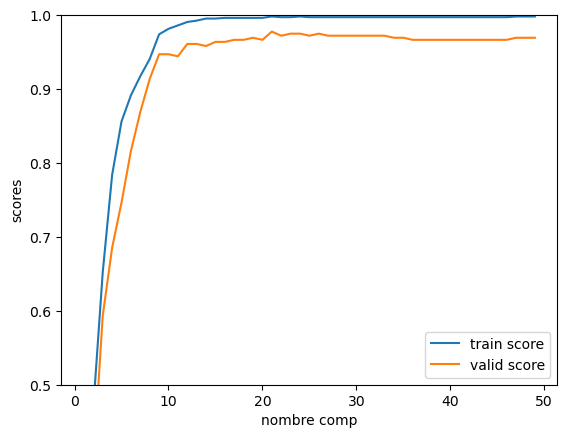

In [49]:
## plot des scores en fonction de l'hyper-param. nc
## c'est cadeau (rien à faire ici)
plt.figure()
plt.plot(n_components_range, linear_training_score, label="train score")
plt.plot(n_components_range, linear_valid_score, label="valid score")
plt.xlabel("nombre comp")
plt.ylabel("scores")
plt.legend()
plt.ylim([0.5, 1])

### Récupération de l'indice du meilleur choix de l'hyper-paramètre `n_components`

Ici on fait l'affichage du meilleur choix d'hyper-param (pour l'ensemble de validation évidemment).
Ici on vous montre un choix primaire, sans tenir compte de l'overfitting, etc: il peut et doit être affiné en observant les courbes (choix "à la main", à l'aide de tracés)


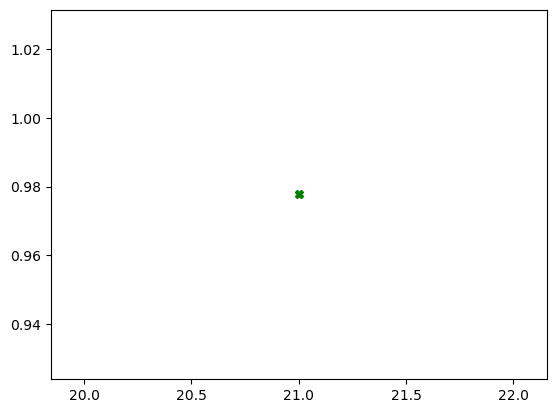

In [51]:
bestIndex = np.argmax(
    linear_valid_score
)  ## on trouve l'indice tel que la performance est la meilleure

bestNC = n_components_range[
    bestIndex
]  ## on récupère la valeur de l'hyper-param qui correspond

plt.plot(
    bestNC, linear_valid_score[bestIndex], marker="X", color="green"
)  ## on affiche le point

## Partie 2 bis: Cross-Validation

On a fait tout ceci pour un partage donné du train et validation set.

Pour être robuste vis-à-vis de l'aléatoire associé au tirage des données, il vaut mieux utiliser la cross-validation. Ceci est vrai en particulier pour les jeux de données avec peu d'exemple (N petit)

- faites un partage (tran+validation)/test des données, de façon déterministe (pas aléatoire), en vous inspirant de la fonction `split_dataset` donnée plus haut.
- faites vous meme une fonction de Cross-Validation:
  - faire un tableaux d'indices de 0 à N-1, mais aléatoire (mélangez les indices. Ça se dit _shuffle_ en anglais)
  - faites une méthode qui permet de piocher de façon déterministe une tranche parmi 5 (par exemple), en choisissant la tranche
  - testez votre fonction (vérifier que quand on demande la tranche 0, puis la 1, ... la 4, ça donne bien tout les exemples du datset, chacun étant vu une seule fois en tant que validation
- Utilisez votre méthode cross_validation:
  - pour une valeur de l'hyper-paramètre, faire 5 tirages train/validation, et mesurer les 5 scores (train+val, donc 10); enregistrer tout ces résultats
  - faire à nouveau la boucle sur les valeurs de l'hyper-paramètre; enregistrer tout


## Partie 3 - OPTIONELLE -Optimisation double: n_components et C

**Il est probablement plus instructif de coder/utiliser la Cross-Validation (partie ci-dessus) que de faire cette optimisation double, ci dessous (qui est assez facile, au demeurant)**

1. Consultez la partie 3 du TP (fichier .ipynb) [vous y êtes!]
2. Vous devez chercher à optimiser à la fois `n_components` et le paramètre `C` asocié à la réglarisation du SVM. Une
   grosse part du travail à déjà été fait. Prenez garde à appliquer la transformation PCA au bon moment,
   de la bonne façon.
3. Le tracé de la figure (score en fonction des deux hyper-paramètres) est déjà fourni. Lisez le attentivement
   (vous pouvez aussi l'améliorer, par exemple en faisant un tracé "en 3D").
4. En cherchant dans la doc de np.argmax et de np.unravel, obtenez les coordonnés du point qui réalise le
   maximum de score, et affichez le.
5. (optionnel) Refaire tout cela mais en utilisant par exemple le modèle des k plus proches voisins (k-NN, cf. la doc. de la classe `sklearn.neighbors.KNeighborsClassifier`, en faisant varier le nombre de voisins au lieu de C).


In [ ]:
n_components_range = np.arange(1, 64, 4)
c_range = [10**k for k in range(-4, 4, 1)]
kernel = "poly"
degree = 2

## si vous suivez cette convention d'enregistrement, le code (donné ci dessous) pour afficher le résultat
## fonctionnera directement. Si vous choisissez une autre convention, il faudra adapter le code..
array_training_score = np.zeros((len(n_components_range), len(c_range)))
array_validation_score = np.zeros((len(n_components_range), len(c_range)))

ratio_train = 0.4
ratio_valid = 0.4
X_train, y_train, X_valid, y_valid, X_test, y_test = split_dataset(
    X, y, ratio_train, ratio_valid
)

In [ ]:
for i, n_components in enumerate(n_components_range):
    X_train_transformed = "COMPLETER"  # TODO
    ## TODO : completer ici
    for j, mu in enumerate(c_range):
        ## TODO: completer ici
        array_training_score[i, j] = trainscore
        array_validation_score[i, j] = validscore

#### On vous donne le code qui affiche la figure (si vous avez suivi ma façon d'enregistrer les résultats)


In [ ]:
### trace de la figure ###
plt.figure()
levels = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1])
# levels=np.arange(0.8,1.0,0.01) ## pour un trace plus fin
plt.contourf(array_validation_score, levels=levels)
architecture = (
    "SVM"  ## on pourrait essayer d'autres classifieurs, comme k-NN par exemple.
)
if architecture == "SVM":
    hyperparam_name = "C (SVM)"
else:
    hyperparam_name = "k (k-NN)"
plt.xlabel("hyper-param " + hyperparam_name)
xtick = np.arange(len(c_range))
plt.xticks(xtick, c_range)
plt.ylabel("num. of Comp (PCA)")
ytick = np.arange(len(n_components_range))
plt.yticks(ytick, n_components_range)
plt.colorbar()
# indice_max = ## TODO chercher par vous meme (ou stackoverflow) comment trouver le argmax d'un tableau a deux entrées
# plt.scatter(indice_max[1],indice_max[0] , marker='X', color='red')
plt.savefig("hyper-param-tuning_arci=" + architecture + ".png")

## Partie 4: avec plus de sklearn

Il était utile de faire tout ça à la main une fois, pour bien comprendre la validation, le pré-processing, mais :

- en fait, on peut automatiser tout ça, par exemple avec `sklearn.model_selection.cross_validate` et `Pipeline`
- lisez la doc et faites tout ça en qq lignes !
- enjoy !
